# 策略 1：红利低波月调组合

按月末最后一个交易日收盘调仓、可用信息截止前一个交易日的口径复刻红利低波月调组合，并与中证红利低波全收益指数比较。请先按需运行 `0_download.ipynb`。

执行口径：每月最后一个交易日收盘调仓，选股和择时信息截止前一个交易日；下文保留的历史输出采用旧调仓及指标口径，需重新运行后更新。

In [1]:
import os
import sys
from pathlib import Path

project_root = next(
    path
    for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").exists()
)
os.chdir(project_root)
source_root = project_root / "src"
if str(source_root) not in sys.path:
    sys.path.insert(0, str(source_root))

In [2]:
from importlib.resources import files

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

from pyquant import calc_metrics, load_dataset
from strategies.div_low_vol.components import (
    calculate_div_low_vol_monthly_rebalanced_index,
    calculate_traditional_volatility_group_indices,
)

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["PingFang SC", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

## 配置与本地数据

In [3]:
file = files("strategies.div_low_vol").joinpath("config.yaml")
with file.open(encoding="utf-8") as stream:
    config = yaml.safe_load(stream)
start_date = pd.Timestamp(config["data"]["start_date"])
end_date = pd.Timestamp(config["data"]["end_date"])
lookback_date = start_date - pd.DateOffset(years=3)

price = load_dataset(
    "stock_daily",
    start=lookback_date.strftime("%Y-%m-%d"),
    end=end_date.strftime("%Y-%m-%d"),
)
dividends = load_dataset("dividend")
dividend_queries = load_dataset("dividend_queries")
market_cap_dates = (
    price.loc[price["date"].lt(start_date), "date"]
    .drop_duplicates()
    .sort_values()
)
market_cap_lookback = int(config["universe"]["lookback_days"])
if len(market_cap_dates) < market_cap_lookback:
    raise ValueError("Not enough local trading dates for the market-cap lookback")
market_cap_start = market_cap_dates.iloc[-market_cap_lookback]
market_cap = load_dataset("stock_market_cap_daily", start=market_cap_start.strftime("%Y-%m-%d"), end=end_date.strftime("%Y-%m-%d"))
adjustment_factors = load_dataset("stock_adjust_factor")
adjustment_factor_coverage = load_dataset("stock_adjust_factor_coverage")
benchmark = (
    load_dataset(
        "csindex_daily",
        start=start_date.strftime("%Y-%m-%d"),
        end=end_date.strftime("%Y-%m-%d"),
        symbols=["H20269"],
    )
    .set_index("date")["close"]
    .rename("红利低波全收益指数")
)

## 月度调仓回测

In [4]:
strategy_index, constituents = calculate_div_low_vol_monthly_rebalanced_index(
    price,
    dividends,
    dividend_queries,
    market_cap,
    start_date,
    end_date,
    config,
    adjustment_factors,
    adjustment_factor_coverage,
)
benchmark_monthly_nav = benchmark.reindex(strategy_index.index).dropna()
curve = pd.concat(
    [
        strategy_index["total_return_index"].rename("红利低波月调组合"),
        benchmark_monthly_nav,
    ],
    axis=1,
).dropna()
curve = curve.div(curve.iloc[0])
returns = pd.concat(
    [
        strategy_index["total_return"].rename("红利低波月调组合"),
        benchmark_monthly_nav.pct_change(fill_method=None),
    ],
    axis=1,
).dropna()
rebalance_dates = constituents.index.get_level_values("effective_date").unique()
monthly_nav = curve.reindex(rebalance_dates).dropna()
monthly_nav = monthly_nav.div(monthly_nav.iloc[0])
monthly_nav.index.name = None

## 收益曲线

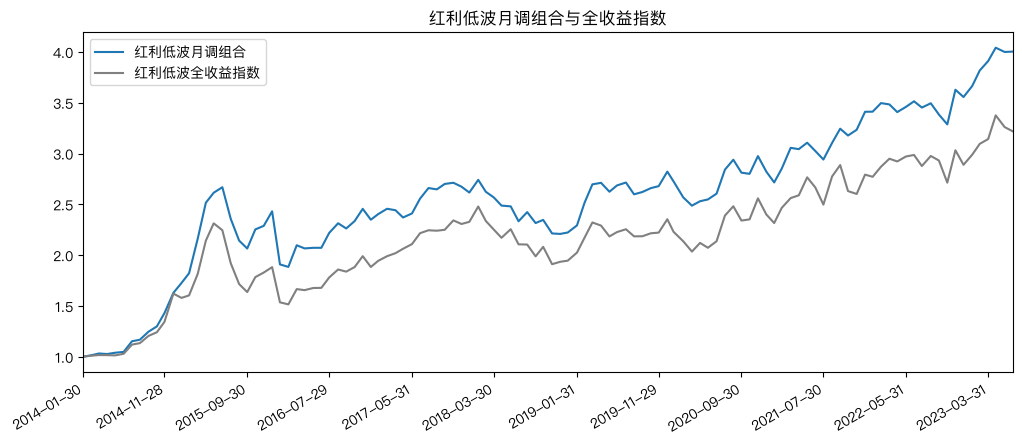

In [5]:
ax = monthly_nav.plot(
    figsize=(12, 5),
    title="红利低波月调组合与全收益指数",
    color={"红利低波月调组合": "C0", "红利低波全收益指数": "#808080"},
    style=["-", "-"],
)
ax.margins(x=0)
ax.set_xlabel("")
ax.set_xlim(monthly_nav.index.min(), monthly_nav.index.max())
ax.set_xticks(monthly_nav.index[::10])
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.figure.autofmt_xdate()
plt.show()

## 绩效对比

所有指标基于月收益，每年按 12 期年化，标准差采用 ddof=0。Sharpe 使用算术平均超额收益，年化无风险收益率默认设为 0；信息比率使用相对 H20269 全收益指数的月度主动收益均值除以其标准差，再乘以 √12。基准自身的跟踪误差为零，信息比率显示为空值。年化收益／年化波动单列为研报对照口径，不等同于 Sharpe 或标准信息比率；原研报定义仍需核对。月度胜率为有效月收益大于零的比例；最大回撤包含初始净值，并以正的损失幅度展示，不能反映月中回撤。

In [6]:
def summarize_performance(monthly_returns):
    metrics = calc_metrics(
        monthly_returns,
        benchmark_returns=returns["红利低波全收益指数"],
        periods_per_year=12,
    )
    return pd.Series({
        "年化收益": metrics["annual_return"],
        "年化波动": metrics["annual_vol"],
        "Sharpe（无风险收益率=0）": metrics["sharpe"],
        "信息比率": metrics["information_ratio"],
        "年化收益／年化波动（研报对照口径）": metrics["return_volatility_ratio"],
        "月度胜率": (monthly_returns.dropna() > 0).mean(),
        "最大回撤": metrics["max_drawdown"],
    })


performance = returns.apply(summarize_performance)
percentage_rows = ["年化收益", "年化波动", "月度胜率", "最大回撤"]
ratio_rows = ["Sharpe（无风险收益率=0）", "信息比率", "年化收益／年化波动（研报对照口径）"]
performance.style.format(
    "{:.2%}", subset=pd.IndexSlice[percentage_rows, :], na_rep="—",
).format(
    "{:.2f}", subset=pd.IndexSlice[ratio_rows, :], na_rep="—",
)


,红利低波月调组合,红利低波全收益指数
年化收益,15.87%,13.22%
年化波动,18.26%,20.10%
信息比率,0.87,0.66
月度胜率,62.83%,61.95%
最大回撤,29.38%,34.48%


## 传统波动率因子分组

分组1对应最低波动率，分组5对应最高波动率；分组2至分组4按波动率从低到高排列，多空对冲为做多分组1、做空分组5。

In [7]:
traditional_volatility_nav = calculate_traditional_volatility_group_indices(
    price,
    dividends,
    dividend_queries,
    market_cap,
    start_date,
    end_date,
    config,
    adjustment_factors,
    adjustment_factor_coverage,
)

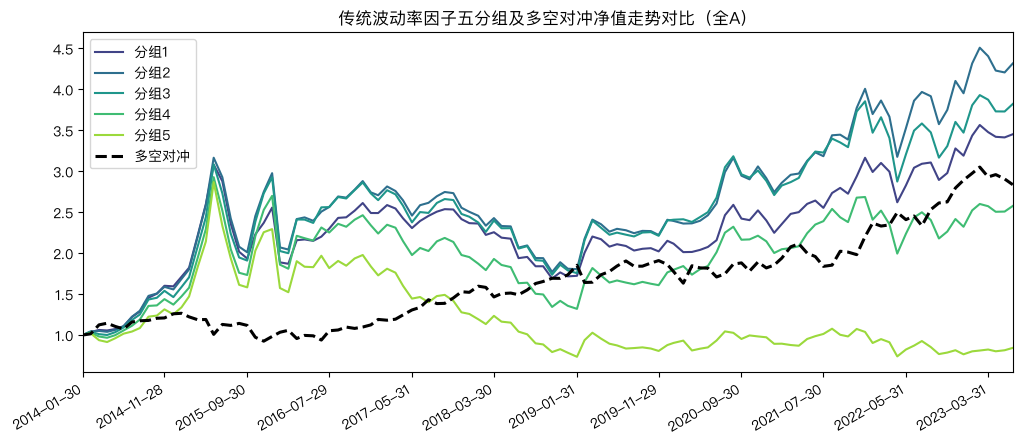

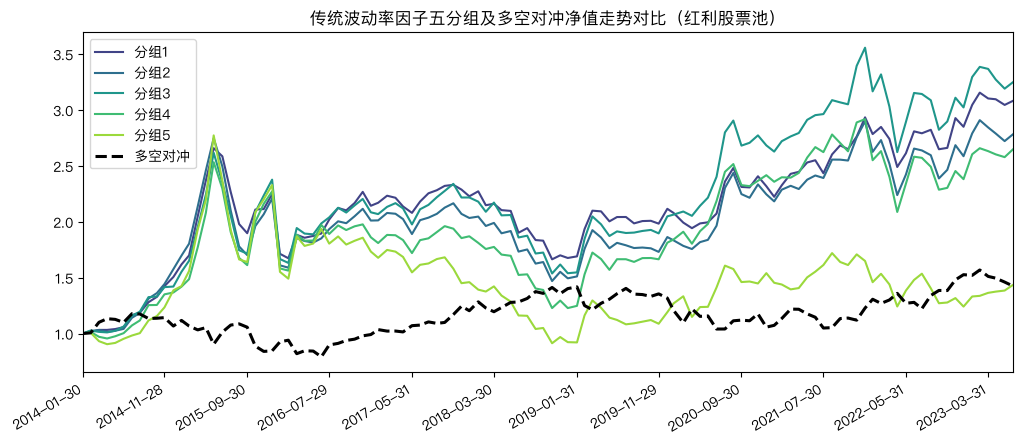

In [8]:
group_labels = ["分组1", "分组2", "分组3", "分组4", "分组5"]
group_colors = plt.cm.viridis(np.linspace(0.2, 0.85, len(group_labels)))

def plot_volatility_groups(nav, title):
    fig, ax = plt.subplots(figsize=(12, 5))
    for column, label, color in zip(nav.columns[:5], group_labels, group_colors):
        ax.plot(nav.index, nav[column], label=label, color=color, linestyle="-")
    ax.plot(
        nav.index,
        nav.iloc[:, -1],
        label="多空对冲",
        color="black",
        linestyle="--",
        linewidth=2.2,
    )
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.margins(x=0)
    ax.set_xlim(nav.index.min(), nav.index.max())
    ax.set_xticks(nav.index[::10])
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    ax.legend()
    fig.autofmt_xdate()
    plt.show()

plot_volatility_groups(traditional_volatility_nav["all_a"], "传统波动率因子五分组及多空对冲净值走势对比（全A）")
plot_volatility_groups(traditional_volatility_nav["dividend_pool"], "传统波动率因子五分组及多空对冲净值走势对比（红利股票池）")

## 传统波动率因子分组表现

收益类指标对应最低波动率的分组1等权组合；IC按月末波动率因子与下个月个股收益计算。

In [9]:
def annual_icir(ic):
    volatility = ic.std(ddof=1)
    return ic.mean() / volatility * np.sqrt(12) if volatility else np.nan

def summarize_factor_performance(nav):
    returns = nav.iloc[:, 0].pct_change(fill_method=None).dropna()
    metrics = calc_metrics(returns, periods_per_year=12)
    ic = nav.attrs["factor_ic"].dropna()
    return pd.Series(
        {
            "年化收益": metrics["annual_return"],
            "年化波动": metrics["annual_vol"],
            "Sharpe（无风险收益率=0）": metrics["sharpe"],
            "年化收益／年化波动（研报对照口径）": metrics["return_volatility_ratio"],
            "月度胜率": (returns > 0).mean(),
            "最大回撤": metrics["max_drawdown"],
            "IC均值": ic["ic"].mean(),
            "年化ICIR": annual_icir(ic["ic"]),
            "Rank IC均值": ic["rank_ic"].mean(),
            "年化Rank ICIR": annual_icir(ic["rank_ic"]),
        }
    )

factor_performance = pd.DataFrame(
    {
        "全体A股": summarize_factor_performance(traditional_volatility_nav["all_a"]),
        "红利股票池": summarize_factor_performance(traditional_volatility_nav["dividend_pool"]),
    }
)
factor_percentage_rows = ["年化收益", "年化波动", "月度胜率", "最大回撤"]
factor_ic_rows = ["IC均值", "Rank IC均值"]
factor_performance.style.format(
    "{:.2%}",
    subset=pd.IndexSlice[factor_percentage_rows, :],
).format(
    "{:.2f}",
    subset=pd.IndexSlice[["Sharpe（无风险收益率=0）", "年化收益／年化波动（研报对照口径）"], :],
).format(
    "{:.3f}",
    subset=pd.IndexSlice[factor_ic_rows + ["年化ICIR", "年化Rank ICIR"], :],
)

,全体A股,红利股票池
年化收益,14.06%,12.69%
年化波动,24.07%,20.75%
信息比率,0.58,0.61
月度胜率,59.29%,61.06%
最大回撤,45.13%,37.41%
IC均值,-0.045,-0.032
年化ICIR,-1.093,-0.639
Rank IC均值,-0.094,-0.071
年化Rank ICIR,-1.992,-1.327
